In [56]:
# импорт основных модулей
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as st

**Задание 2**

Имеются результаты `A/B теста`, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что `ARPU` в тестовой группе выше на `5%`, чем в контрольной. При этом в контрольной группе `1928` игроков из `202103` оказались платящими, а в тестовой – `1805` из `202667`. Какой набор предложений можно считать лучшим? Какие метрики следует проанализировать?

In [2]:
df_main = pd.read_csv('./Проект_1_Задание_2.csv', sep=';')

In [3]:
df_main.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


Для начала проверим метрику **Conversion Rate (Конверсия в платящего)**, используя данные из условия.

In [4]:
# Имеем по условию для контрольной группы
count_pay_control = 1928
count_main_control = 202103
percent_pay_users_control = round((count_pay_control / count_main_control) * 100, 2)
print(f"CR в процентах для контрольной группы: {percent_pay_users_control} %")

# Имеем по условию для тестовой группы
count_pay_test = 1805
count_main_test = 202667
percent_pay_users_test = round((count_pay_test / count_main_test) * 100 , 2)
print(f"CR в процентах для тестовой группы: {percent_pay_users_test} %")

# Разница между тестовым и контрольным CR в процентах
diff_CR = (percent_pay_users_control - percent_pay_users_test) * 100 / percent_pay_users_control
print(f"Разница CR между контрольной и тестовой группами:{round(diff_CR, 2)} %")

CR в процентах для контрольной группы: 0.95 %
CR в процентах для тестовой группы: 0.89 %
Разница CR между контрольной и тестовой группами:6.32 %


**Первоначальный вывод**

В тестовой выборке `CR` упал на 6 %. При этом имеем, что `ARPU` вырос на 5 %. Из этого можно сделать вывод, что метрика `ARPPU` (Average Revenue Per Paying User)  неизбежно `выросла`. Т.е. платящих пользователей стало меньше, однако оставшиеся плательшики стали тратить больше!


Проведем `первичный анализ данных`, `определим распределения` в контрольной и тестовой выборках, а так же `проверим стат. значимость` различий по следующим метрикам: 
1. **Conversion Rate**
2. **ARPU**
3. **ARPPU**

**Проведем первичный EDA имеющихся данных**

In [42]:
# платящие пользователи контрольной группы
df_control = df_main[(df_main['testgroup'] == 'a') & (df_main['revenue'] > 0)]
# платящие пользователи тестовой группы
df_test = df_main[(df_main['testgroup'] == 'b') & (df_main['revenue'] > 0)]

In [45]:
# Сравним показатели в контрольной и тестовой группе по доходу среди платящих
print(f"Минимальный доход в контрольной группе: {df_control['revenue'].min()}")
print(f"Медианный доход в контрольной группе: {df_control['revenue'].median()}")
print(f"Максимальный доход в контрольной группе: {df_control['revenue'].max()}")

print(f"Минимальный доход в тестовой группе: {df_test['revenue'].min()}")
print(f"Медианный доход в тестовой группе: {df_test['revenue'].median()}")
print(f"Максимальный доход в тестовой группе: {df_test['revenue'].max()}")

Минимальный доход в контрольной группе: 200
Медианный доход в контрольной группе: 311.0
Максимальный доход в контрольной группе: 37433
Минимальный доход в тестовой группе: 2000
Медианный доход в тестовой группе: 3022.0
Максимальный доход в тестовой группе: 4000


`Медианный доход` среди платящих в тестовой группе `вырос ~ в 10 раз` по сравнению с контрольной группой. Однако `максимальное` значение дохода упало `~ в 9 раз` .

Проведем визуализацию полученных данных с помощью `Boxplot`. `Boxplot` показывает минимальное значение распределения, первый перцентиль, медиану, третий перцентиль и максимальное значение.

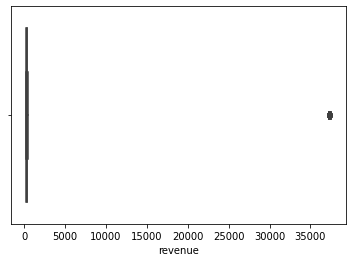

In [44]:
# Построим Boxplot по значениям revenue в контрольной группе
sns.boxplot(x=df_control['revenue'])

In [47]:
# Видим довольно существенный выброс с пользователями, которые заплатили больше 35000
# Подсчитаем кол-во пользователей в этом выбросе
df_control[df_control['revenue'] > 35000].revenue.count()

123

In [48]:
# Подсчитаем процент дохода, который приносили эти пользователи
per_rev_top_users = df_control[df_control['revenue'] > 35000].revenue.sum() * 100 / df_control.revenue.sum()
print(f"Процент дохода от наиболее платящих: {per_rev_top_users}")

Процент дохода от наиболее платящих: 89.37077665950378


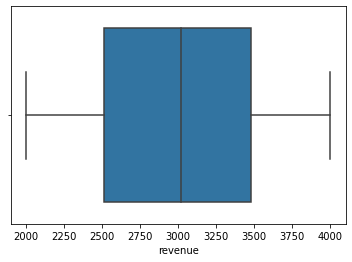

In [46]:
# Построим Boxplot по значениям revenue в тестовой группе
sns.boxplot(x=df_test['revenue'])

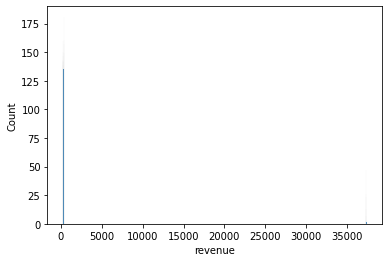

In [49]:
# Построим график распределения revenue для контрольной выбороки
# по платящим пользователям
sns.histplot(data=df_control, x='revenue', label='control')

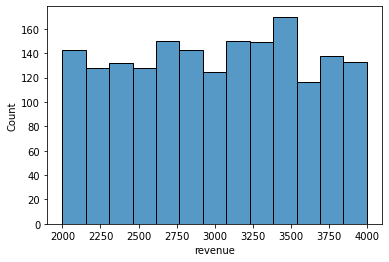

In [50]:
# для тестовой выборки по платящим пользователям
sns.histplot(data=df_test, x='revenue')

 Из графиков видно, что в `контрольной группе` распределение `не равномерное`. `123 пользователя` обеспечивают почти `90 %` всего дохода в выборке. В `тестовой группе` распределение стало более равномерным: `китов`, которые генерируют большое количество дохода больше нет, зато `медиана` существенно выросла. 

**1. Проверим стат. значимость различий в Conversion Rate**

Определим, есть ли стат. значимые различия между **Conversion Rate**. В стат смысле **Conversion Rate** - это бинарная переменная, которая равна 1, если пользователь платит, 0 - если не платит. Т.о. анализа данной категориальной переменной будет разумно использовать критерий `Хи-квадрат`.

In [51]:
# используем исходный датасет
df_main['CR'] = np.where(df_main['revenue'] > 0, 1, 0)

In [52]:
df_main.head()

,user_id,revenue,testgroup,CR
0,1,0,b,0
1,2,0,a,0
2,3,0,a,0
3,4,0,b,0
4,5,0,b,0


In [53]:
# строим таблицу сопряженности 
# (стандартная таблица для теста хи-квадрат)
contingency = pd.crosstab(df_main['testgroup'], df_main['CR'])

In [54]:
contingency

CR,0,1
testgroup,,
a,200175,1928
b,200862,1805


In [55]:
# Применяем критерий хи-квадрат

# первый вывод - это значение Хи-квадрата
# второй вывод - это полученное p-value
st.chi2_contingency(contingency)

(4.374729521260405,
 0.03647561892312613,
 1,
 array([[200239.10075104,   1863.89924896],
        [200797.89924896,   1869.10075104]]))

In [20]:
# p-value = 0.036 < 0.05 -> мы имеем достаточные основания, чтобы отвергнуть H0.

**Вывод:** Значения `Conversion Rate` статистически значимо отличаются. Тестовая выборка показывает худший результат.

**2. Проверим стат. значимость различий в ARPU**

`ARPU` - это `средняя выручка` на одного пользователя. 

Для проверки стат. значимости различий по `ARPU` будем использовать двухвыборочный `t-test` , который хорошо подходит для сравнения `средних` при большом кол-ве элементов в выборках. В нашем случае размеры групп A/B теста примерно одинаковые и большие (около 202 тыс. пользователей в каждой). Следовательно, ни отклонения от нормальности, ни различия в дисперсиях не скажутся на адекватности критерия.

In [61]:
# Рассчитаем ARPU для тестового и контрольного набора данных
a_main = df_main[df_main['testgroup'] == 'a'].revenue
b_main = df_main[df_main['testgroup'] == 'b'].revenue

ARPU_control = a_main.mean()
ARPU_test = b_main.mean()

# Получаем разницу между группами в процентах
ARPU_diff = round((ARPU_test - ARPU_control) * 100 / ARPU_test , 2)

print(f"Средняя выручка на пользователя в контрольной группе: {ARPU_control.round(2)}")
print(f"Средняя выручка на пользователя в тестовой группе: {ARPU_test.round(2)}")
print(f"Разница между двумя группами в процентах: {ARPU_diff.round(0)} %")

Средняя выручка на пользователя в контрольной группе: 25.41
Средняя выручка на пользователя в тестовой группе: 26.75
Разница между двумя группами в процентах: 5.0 %


In [63]:
# проводим t-test
st.ttest_ind(a_main, b_main)

Ttest_indResult(statistic=-0.6242026493616787, pvalue=0.532494858971837)

In [ ]:
# p-value = 0.532 > alpha = 0.05 -> мы не можем отвергнуть гипотезу H0.

**Вывод**: `p-value` > 0.05 -> между средними значениями нет стат. значимых различий. Таким образом, показатели `ARPU` `не имеют стат. отличий`.

**3. Проверим стат. значимость различий между ARPPU**

`ARPPU` - средняя выручка на одного **платящего** пользователя. Количество платящих гораздо меньше, чем общее количество пользователей (1805 в тестовой и 1928 в контрольной группе). При этом в контрольной выборке присутствует `выброс` в виде 123 наиболее платежеспособных пользователей.

In [68]:
percent_of_top_customers = 123 * 100 / 1928
percent_of_top_customers

6.3796680497925315

Имеем достаточно большой выброс в `6 %` от числа платящих, который не позволяет использовать классический `t-test`.
Поэтому для определения стат. значимости будем использовать `Bootstrap`.

In [69]:
# Подсчитаем ARPPU для тестовой и контрольной выборок
ARPPU_control = df_control.revenue.mean()
ARPPU_test = df_test.revenue.mean()

ARPPU_diff = round((ARPPU_test - ARPPU_control) * 100 / ARPPU_test, 2)

In [70]:
print(ARPPU_control.round(2))
print(ARPPU_test.round(2))
print(ARPPU_diff.round(1))
# в тестовой выборке ARPPU больше на 11 процентов

2664.0
3003.66
11.3


In [86]:
# функция статистики для подсчета разности между двумя средними
def my_statistic(sample1, sample2, axis=-1):
    mean1 = np.mean(sample1, axis=axis)
    mean2 = np.mean(sample2, axis=axis)
    return mean1 - mean2

In [89]:
# по умолчанию используем 10 тыс итераций и 95 % уровень значимости
data = (df_control.revenue, df_test.revenue)
st.bootstrap(data, my_statistic, method='basic')

BootstrapResult(confidence_interval=ConfidenceInterval(low=-742.3660086953022, high=65.5023156199353), standard_error=207.24260709799432)

**Вывод:** границы доверительного интервала `включают 0`. Следовательно, мы `не можем отвергнуть H0`. Различия по `ARPPU` не являются статистически значимыми.

**Итоговый вывод**

В результате исследования данных было получено, что метрики `ARPU` и `ARPPU` **не имеют стат. значимых различий** при сравнении тестовой и контрольной групп. При этом `Convertion Rate` двух выборок стат. значимо отличаются, для тестовой выборки этот показатель `меньше`. Однако в тестовой выборке имеем более равномерное распределение среди платящих пользователей, выбросы отсутсвтуют.

По моему мнению, лучше оставить **контрольный набор** предложений, так как:
1. Существенного профита от внесения изменений нет.
2. `Convertion Rate` в тестовой выборке уменьшился. 
3. Лояльные и максимально платежеспособные пользователи сохранены.